# IOAI — 2025 Lab Lab2 Image Segmentation (Colab 자동 설정판)

아래 **설정 셀을 먼저 실행**하면 공개 데이터 소스에서 데이터를 받아 이 폴더에 `train.csv`/`test.csv` 등으로 준비합니다. 이후 셀이 그대로 학습/예측하고, 만들어진 제출 파일을 내려받아 연습 사이트 **Submissions** 탭에 올리면 채점됩니다.

> 런타임 메뉴 → **런타임 유형 변경 → GPU** (필요 시).

In [ ]:
# === 데이터 자동 준비 (가장 먼저 실행) ===
!pip -q install albumentations
print('데이터(leaf-segmentation-dataset.zip)는 노트북 셀이 공개 GCS 에서 자동 다운로드합니다.')
import os; print('작업 폴더:', os.getcwd()); print('내용:', sorted(os.listdir('.')))

# Assembling a FCN network

## Download data

In [ ]:
!curl https://storage.googleapis.com/aiolympiadmy/ioai-2025-tsp/leaf-segmentation-dataset.zip -o leaf-segmentation-dataset.zip

In [ ]:
!unzip -n leaf-segmentation-dataset.zip

## Load and inspect data

Data is given to you in a `trainval/` and `test/` subdir. Images are named `*_rgb.png` while their foreground masks (_what does this mean?_) are given in `*_fg.png`. 

Use this section to figure out what you need / want to know about the data.

In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


## Create your dataset and dataloaders

You've done the Pytorch 60 mins blitz right? Implement your dataset and dataloaders here. From the `trainval/` folder, split your data in an 80/20 split so that you have a train dataset and a validation dataset from this folder. Load your test dataset from `test/`.

You can test the shape of your tensors in the dataset like so:

```python
batch_X, batch_y = next(iter(train_dataset))
print(batch_X.shape, batch_y.shape)
```

Make sure your shape output makes sense!

> Albumentations requires Python 3.9 or higher.

We use Albumentations here as it is easier to ensure the image and mask undergo the same transformation than using `torchvision.transforms`.

In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


> The cell below may take a few seconds to run the first time. Subsequent runs will be instant due to caching.

In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


## Create the network

Define an FCN network by completing the class definition below.

Use a ResNet34 pretrained on ImageNet as the backbone, taking care to remove the final pooling layer and dense layer.

Make sure that the FCN head's tensor input size is the same as the backbone's output size.

Specify the FCN head with two layers:
+ a 1x1 convolution layer, to transform the number of output channels into the number of segmentation classes
+ a transpose convolution layer to upsample the feature maps to the size of the input image. Add a bilinear interpolation here if you need it (I did not work out the math on the image sizing, that's left to you)

In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


### Explore

In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In the traversal above , the `downsample` block is skipped because it is a shortcut connection used for residual addition. It doesn't represent a distinct forward path layer like the main `conv` or `maxpool` layers.

Here is the implementation from the `forward` method in the `torchvision.models.resnet.BasicBlock` class:

```python
def forward(self, x: Tensor) -> Tensor:
    identity = x

    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)

    out = self.conv2(out)
    out = self.bn2(out)

    if self.downsample is not None:
        identity = self.downsample(x)

    out += identity
    out = self.relu(out)

    return out
```
*(quoted from [pytorch.org](https://pytorch.org/vision/stable/_modules/torchvision/models/resnet.html))*

In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In the code above, the `Unflatten` operation is used to reshape the tensor back into a 4D tensor with the shape `(batch_size, 512, 7, 7)` before passing it through the subsequent layers. This reshaping is necessary to do so because the `backbone` ResNet model flattens the output to a 2D tensor with shape `(batch_size, 25088)`.

Here is the implementation of the `forward` method in the `torchvision.models.resnet.ResNet` class:

```python
def _forward_impl(self, x: Tensor) -> Tensor:
    # See note [TorchScript super()]
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.maxpool(x)

    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    x = self.layer4(x)

    x = self.avgpool(x)
    x = torch.flatten(x, 1)
    x = self.fc(x)

    return x

def forward(self, x: Tensor) -> Tensor:
    return self._forward_impl(x)
```
*(quoted from [pytorch.org](https://pytorch.org/vision/stable/_modules/torchvision/models/resnet.html))*

In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


### Implement Dice loss

$$
\textrm{Dice\ Loss} = 1 - \underbrace{\frac{2 |X \cap Y|}{|X| + |Y|}}_{\mathrm{Dice\ coefficient}} = 1 - \frac{2 TP}{2 TP + FP + FN}
$$

For continuous values between 0 and 1, we replace the set operations with element-wise operations:

$$
\textrm{Soft\ Dice\ Loss} = 1 - \frac{2 \sum_{i} y_i \hat{y_i}}{\sum_{i} y + \sum_{i} \hat{y_i}}
$$

where $y_i$ is the ground truth value (0 or 1) and $\hat{y_i}$ is the predicted value (between 0 and 1). Here, each $i$ corresponds to a pixel on the image.

#### Gradient descent

Using quotient rule, differentiate w.r.t. an arbitrary $\hat{y_i}$:

$$
\begin{aligned}
\frac{\partial}{\partial \hat{y_i}} \mathcal{L_{\mathrm{Dice}}}(y_i, \hat{y_i}) &= \frac{-2y_i(\sum_{i} y + \sum_{i} \hat{y_i}) + 2 \sum_{i} y_i \hat{y_i}}{(\sum_{i} y + \sum_{i} \hat{y_i})^2}
\end{aligned}
$$

*I’m including this derivation here for future reference, even though it isn’t needed for this part of the lab.*

In [ ]:
# TODO: 여기에 풀이를 작성하세요


### Establish a train-validation-test pipeline

In [ ]:
import os
import torch.optim as optim
from tqdm import tqdm

Please allow me to reuse the structure from the previous lab with some modifications:

In [ ]:
# TODO: 여기에 풀이를 작성하세요


## Verify that you can load a single image and pass it through the network

Neural networks are like a system of pipes. This section is here as a sanity check to ensure that your layers are assembled correct enough for information to flow from top to bottom before you do anything more. 

Also, have you taken care of ImageNet normalization and the variable image sizes in the dataset?

In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


Things work fine.

## Obtain a baseline performance of your FCN network

Select an appropriate metric to gauge your FCN network's performance, then measure baseline performance on the testing set. Your FCN head is untrained at this point, so its performance should not be flattering. But you'll change that in the next section!

In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


## Finetuning

Finetune this FCN network using data in `leaf-segmentation-dataset/trainval`. Store the following info every 10 minibatches: loss (choose an appropriate loss function), intersection over union (Jaccard's index), and Dice loss. During training, collect the above metrics on both your train dataset and your validation dataset. When you are done training, check your network performance on your test dataset.

Make sure you are running on GPU! Use Google Colab if you don't have access to a GPU computer. Will leave it to you on exactly how you want to implement finetuning. Run finetuning that will finish within 15, 20 minutes, don't need to finetune for too long.

---

Using Optuna and some manual testing, this set of hyperparameters performs well for the task:

In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


## Writeup

Summarize what you did above, as well as detail the choices you made and why. Concise descriptions in one paragraph is enough :)

---

*Apologies for the long-winded response—there's just too much to squeeze into a single paragraph!*

### Network architecture

We employ a Fully Convolutional Network (FCN) for semantic segmentation, using ResNet34 as the backbone. The input is an image of size $224\times224\times3$, and the model produces a $7\times7\times512$ feature map. A $1\times1$ convolutional layer is then applied to reduce the channel dimension to $3$, followed by a transposed convolution layer to upsample the output back to the original input size.

The transposed convolution follows the formula:

$$
224 = 6s – 2p + k
$$

where $s$ is stride, $p$ is padding and $k$ is kernel size. However, to allow more flexibility in choosing $s$, $p$, and $k$, we used a bilinear interpolation. This relaxes the constraints on transposed convolution by changing the $=$ sign above to $\ge$ sign.

### Evaluation metric

To account for the **large variability in leaf sizes** within the test set, we use a **weighted IoU metric**. Each sample's contribution to the overall score is weighted by the number of ground-truth leaf pixels it contains. This approach provides a more faithful representation of model performance, especially compared to the “average” IoU (which computes the IoU for each sample and averages them), found to over-penalize performance on smaller leaves, and the “micro” IoU (which takes all samples as a whole and computes IoU), which tends to under-penalize due to the dominance of large leaves with more leaf pixels.

### Image augmentation

A key component of our preprocessing pipeline is HSV color segmentation. We reduce the V (brightness) channel for non-green pixels to emphasize leaf regions. This preprocessing step significantly boosts model performance, increasing the IoU score by at least 0.25.

That said, the effectiveness of this step also highlights a concerning dependency: **performance is highly sensitive to HSV thresholds**. The model is over-reliant on the color-based preprocessing, rather than learning robust semantic features. In fact, it is likely that a simple deterministic HSV segmentation combined with morphological opening outperforms the model alone in most cases.

### Challenges

There are three majors sources of error which affects model performance:

1. Sharp and jagged edges in the segmentation masks.
2. Misclassification of moss as leaves.
3. Failure to detect bud leaves, which are often only a few pixels wide.

Challenges 1 and 3 are addressed effectively using the techniques described in the next section. However, for Challenge 2, I attempted to augment the dataset by adding artificial moss lumps:

```python
class RandomMossLumps(ColorEnhance):
    def __init__(self, n_lumps, max_blobs_per_lump, lower_hsv, upper_hsv, radius_range=(1, 3), spread_range=(-15, 15), p=0.8):
        super().__init__(lower_hsv, upper_hsv, p=p)
        self.n_lumps = n_lumps
        self.max_blobs_per_lump = max_blobs_per_lump
        self.radius_range = radius_range
        self.spread_range = spread_range


    def random_blob_color(self):
        h = random.randint(self.lower_hsv[0], self.upper_hsv[0])
        s = random.randint(self.lower_hsv[1], self.upper_hsv[1])
        v = random.randint(self.lower_hsv[2], self.upper_hsv[2])
        hsv = np.uint8([[[h, s, v]]])
        return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)[0, 0]
    
    
    def get_params_dependent_on_data(self, params, data):
        params["mask"] = data["mask"]
        return params
    
        
    def apply(self, image, **params):
        mask = params.get("mask", None)
        height, width = image.shape[:2]
        for _ in range(self.n_lumps):
            # center of a lump
            cx, cy = random.randint(0, width - 1), random.randint(0, height - 1)

            for _ in range(self.max_blobs_per_lump):
                dx = random.randint(*self.spread_range)
                dy = random.randint(*self.spread_range)
                x = np.clip(cx + dx, 0, width - 1)
                y = np.clip(cy + dy, 0, height - 1)
                r = random.randint(*self.radius_range)
    
                if mask is not None and mask[y, x, 0] != 0:
                    continue  # Don't draw on masked area
                
                color = self.random_blob_color()
                # Draw blob
                cv2.circle(image, (x, y), r, color.tolist(), -1)
        return image
```

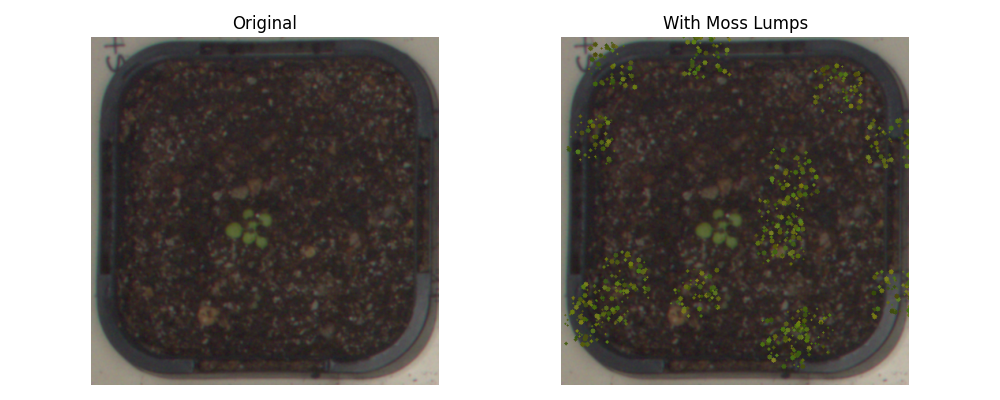

Unfortunately, this approach did not help the model improve its performance. the model is unable to learn the distinct characteristics of leaves compared to moss under the current setup.

### A better inference technique

To address both edge artifacts and the detection of small features (e.g., bud leaves), we introduced a **multiscale sliding window with soft voting**. During inference, the input images are zoomed at various factors and passed through sliding windows, with the probabilities for each zoom level being averaged to produce the final prediction.

Performance improved with both the zoom factor and the number of scales used, ultimately achieving an IoU score of about 0.77 on the test set.

## EX: Residual pathways

Here's something for you if you want to explore further.

FCNs are very simple and have some key architectural limitations. Depending on how your structured your network or processed your images, you might hit a performance limit even in this fairly simple dataset, even if you implement aggressive augmentations (_what's that?_). Try circumventing these limitations by implementing residual connections (_google me!_) in your network.

### Setup

In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


### Finetuning

In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


In [ ]:
# TODO: 여기에 풀이를 작성하세요


### Conclusion

The network is structured as follows:

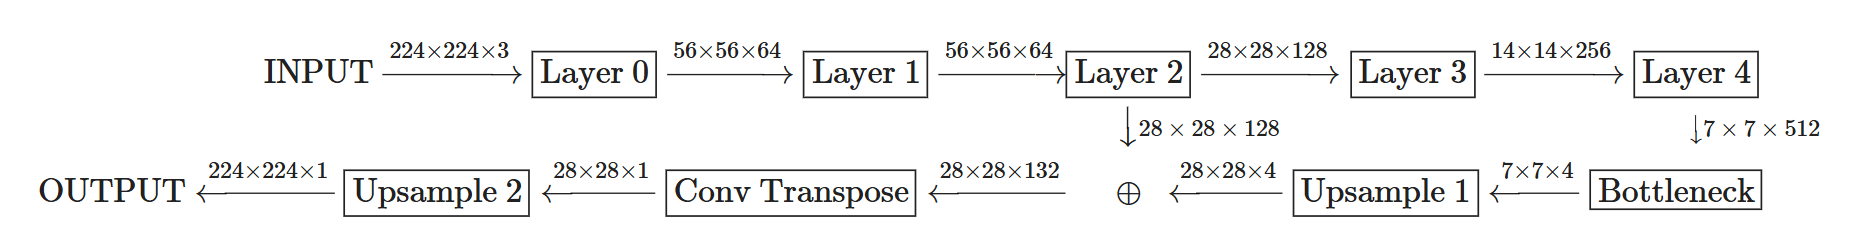

<!--
$$
\begin{aligned}
\text{INPUT} \xrightarrow{224\times224\times3} \boxed{\text{Layer\ 0}} \xrightarrow{56\times56\times64} \boxed{\text{Layer\ 1}} \xrightarrow{56\times56\times64} &\boxed{\text{Layer\ 2}} \xrightarrow{28\times28\times128} \boxed{\text{Layer\ 3}} \xrightarrow{14\times14\times256} \boxed{\text{Layer\ 4}}\\
&\ \ \ \ \ \ \big\downarrow \tiny{28\times28\times128} \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \big\downarrow \tiny{7\times7\times512} \\
\text{OUTPUT} \xleftarrow{224\times224\times1} \boxed{\text{Upsample 2}} \xleftarrow{28\times28\times1} \boxed{\text{Conv\ Transpose}} \xleftarrow{28\times28\times132} &\ \ \ \ \ \oplus\ \xleftarrow{28\times28\times4} \boxed{\text{Upsample 1}} \xleftarrow{7\times7\times4} \boxed{\text{Bottleneck}}
\end{aligned}
$$
-->

where $\oplus$ denotes the stacking of the outputs from two layers.

With the addition of the residual connection, the model achieves a weighted IoU score of 0.82 without any data augmentation. Moreover, a significantly larger proportion of test images achieve scores above 0.8 compared to the previous model. Images with very low scores are primarily those containing bud leaves, which cannot be resolved simply by applying zoom during inference. This suggests that the model is learning meaningful leaf features rather than relying solely on color cues.

## 제출 파일 모으기
아래 셀을 실행하면 제출 파일이 **최상위(`/content`)로 복사**되어 왼쪽 파일 탐색기에 바로 보입니다.
그 파일을 내려받아 연습 사이트 **Submissions** 탭에 올리면 채점됩니다.

In [ ]:
# === 제출 파일을 /content 로 모으기 (마지막에 실행) ===
import os, glob, shutil
TARGETS = ['submission.csv', 'submission.zip', 'submission.jsonl', 'submission.json']
OUT = "/content" if os.path.isdir("/content") else os.getcwd()
found = []
for name in TARGETS:
    hits = [name] if os.path.exists(name) else glob.glob(f"**/{name}", recursive=True)
    if not hits:
        print("아직 없음(해당 셀을 먼저 실행하세요):", name); continue
    dst = os.path.join(OUT, os.path.basename(hits[0]))
    if os.path.abspath(hits[0]) != os.path.abspath(dst):
        shutil.copy2(hits[0], dst)
    found.append(dst)
print("제출 파일 저장 위치(파일 탐색기 최상위):", found)